# **House Price Regression Dataset**





**Import Libraries**

In [50]:
# Basic libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**Load the Dataset**

In [124]:
df = pd.read_csv("house_price_regression_dataset.csv")
df

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06
...,...,...,...,...,...,...,...,...
995,3261,4,1,1978,2.165110,2,10,7.014940e+05
996,3179,1,2,1999,2.977123,1,10,6.837232e+05
997,2606,4,2,1962,4.055067,0,2,5.720240e+05
998,4723,5,2,1950,1.930921,0,7,9.648653e+05


# **Basic Checks**

In [151]:
df.shape

(1000, 8)

In [102]:
df.head()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


In [54]:
df.tail()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
995,3261,4,1,1978,2.165110,2,10,701493.997069
996,3179,1,2,1999,2.977123,1,10,683723.160704
997,2606,4,2,1962,4.055067,0,2,572024.023634
998,4723,5,2,1950,1.930921,0,7,964865.298639
999,3268,4,2,1983,3.108790,2,2,742599.253332


In [121]:
print(df.columns)

Index(['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms', 'Year_Built',
       'Lot_Size', 'Garage_Size', 'Neighborhood_Quality', 'House_Price'],
      dtype='object')


In [139]:
df.dtypes

,0
Square_Footage,int64
Num_Bedrooms,int64
Num_Bathrooms,int64
Year_Built,int64
Lot_Size,float64
Garage_Size,int64
Neighborhood_Quality,int64
House_Price,float64


In [115]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Square_Footage        1000 non-null   int64  
 1   Num_Bedrooms          1000 non-null   int64  
 2   Num_Bathrooms         1000 non-null   int64  
 3   Year_Built            1000 non-null   int64  
 4   Lot_Size              1000 non-null   float64
 5   Garage_Size           1000 non-null   int64  
 6   Neighborhood_Quality  1000 non-null   int64  
 7   House_Price           1000 non-null   float64
dtypes: float64(2), int64(6)
memory usage: 62.6 KB


In [57]:
df.describe()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,2815.422000,2.990000,1.973000,1986.550000,2.778087,1.022000,5.615000,6.188610e+05
std,1255.514921,1.427564,0.820332,20.632916,1.297903,0.814973,2.887059,2.535681e+05
min,503.000000,1.000000,1.000000,1950.000000,0.506058,0.000000,1.000000,1.116269e+05
25%,1749.500000,2.000000,1.000000,1969.000000,1.665946,0.000000,3.000000,4.016482e+05
50%,2862.500000,3.000000,2.000000,1986.000000,2.809740,1.000000,6.000000,6.282673e+05
75%,3849.500000,4.000000,3.000000,2004.250000,3.923317,2.000000,8.000000,8.271413e+05
max,4999.000000,5.000000,3.000000,2022.000000,4.989303,2.000000,10.000000,1.108237e+06


# **Handle Missing Values**

In [58]:
# Check missing values
df.isnull().sum()

,0
Square_Footage,0
Num_Bedrooms,0
Num_Bathrooms,0
Year_Built,0
Lot_Size,0
Garage_Size,0
Neighborhood_Quality,0
House_Price,0


In [59]:
# Fill missing values (numeric → mean)
df.fillna(df.mean(numeric_only=True), inplace=True)

In [60]:
# For categorical → mode
for col in df.select_dtypes(include='object').columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

# **Remove Duplicates Records**

In [152]:
df.duplicated().sum()

np.int64(0)

In [62]:
df.drop_duplicates(inplace=True)

# **Univariate Analysis**

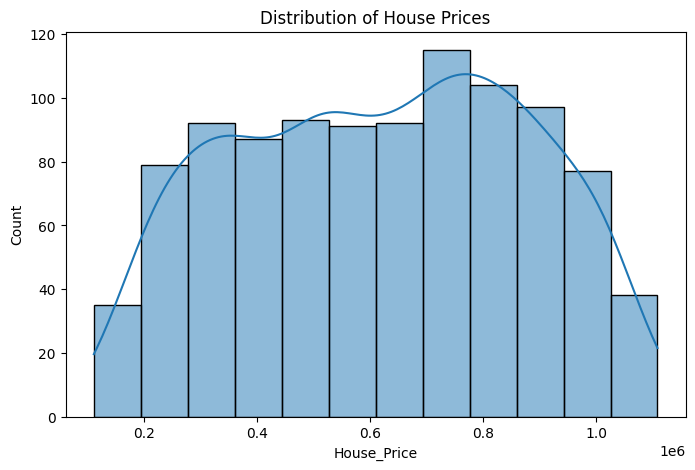

In [108]:
# Histogram of house prices
plt.figure(figsize=(8,5))
sns.histplot(df['House_Price'], kde=True)
plt.title("Distribution of House Prices")
plt.show()




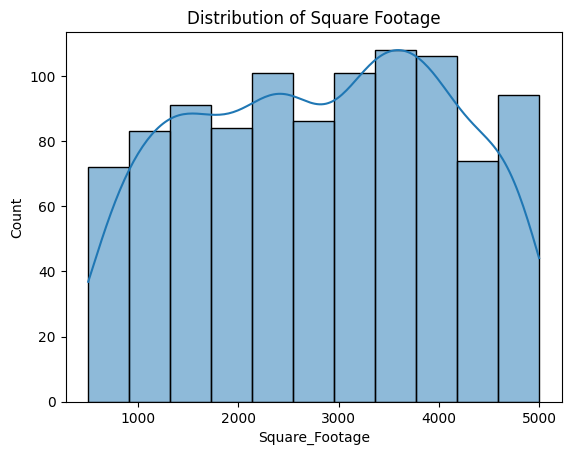

In [109]:
# Check distribution of square footage
sns.histplot(df['Square_Footage'], kde=True)
plt.title("Distribution of Square Footage")
plt.show()

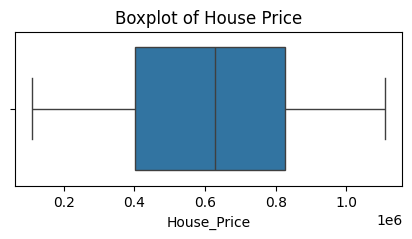

In [141]:
# House Price
plt.figure(figsize=(5,2))
sns.boxplot(df, x='House_Price')
plt.title("Boxplot of House Price")
plt.show()

# **Bivariate Analysis**

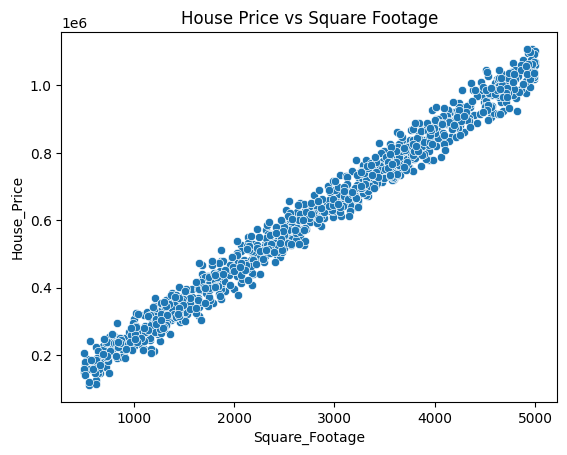

In [135]:
sns.scatterplot(x='Square_Footage', y='House_Price', data=df)
plt.title("House Price vs Square Footage")
plt.show()



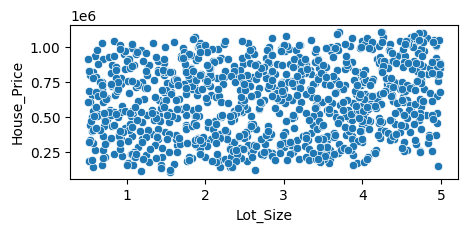

In [144]:
# Lot Size vs House Price
plt.figure(figsize=(5,2))
sns.scatterplot(df, x='Lot_Size', y='House_Price')
plt.show()

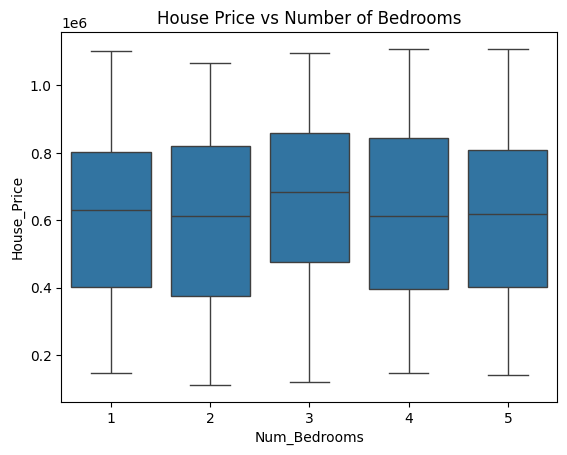

In [111]:
sns.boxplot(x='Num_Bedrooms', y='House_Price', data=df)
plt.title("House Price vs Number of Bedrooms")
plt.show()


# **Correlation Heatmap**

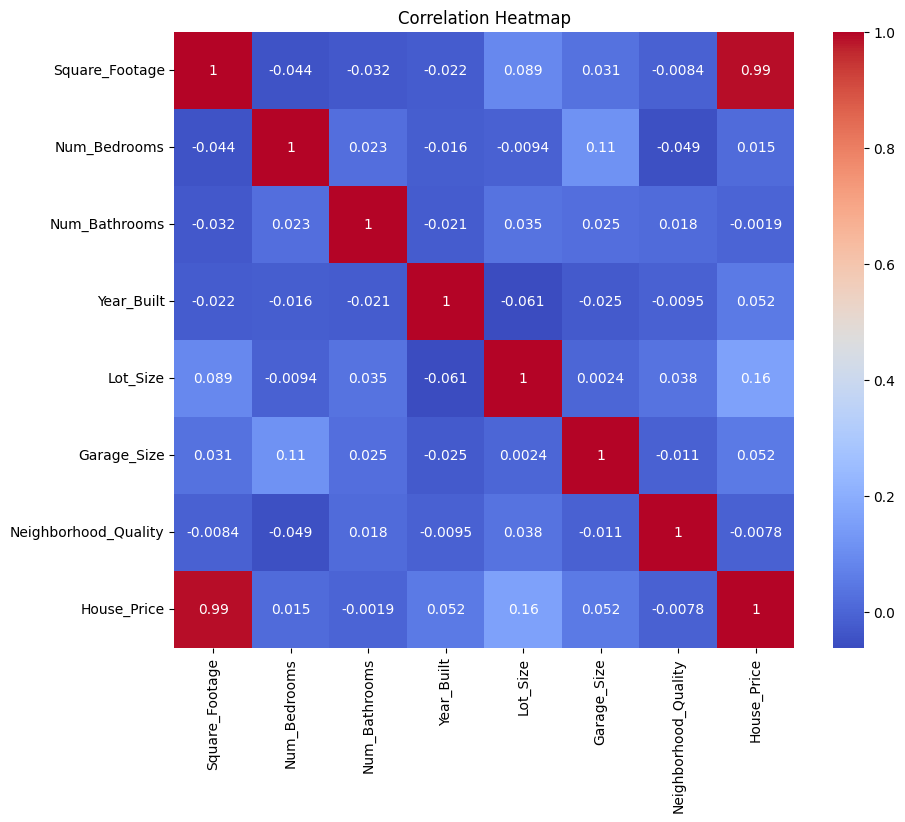

In [76]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# **Detect and Handle Outliers**

**Detect Outliers**

In [153]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Count outliers in each column
outliers = ((df < lower_bound) | (df > upper_bound))
print(outliers.sum())

Square_Footage          0
Num_Bedrooms            0
Num_Bathrooms           0
Year_Built              0
Lot_Size                0
Garage_Size             0
Neighborhood_Quality    0
House_Price             0
dtype: int64


**Handle Outliers**

# **Encoding**

In [119]:
from sklearn.preprocessing import LabelEncoder

In [106]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

# **Log Transformation**

In [82]:
# Apply log to skewed columns (example: price)
df['House_Price'] = np.log1p(df['House_Price'])

# **Separate Features & Target**

In [83]:
X = df.drop('House_Price', axis=1)
y = df['House_Price']

# **Train Test split**

In [84]:
from sklearn.model_selection import train_test_split

In [85]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [86]:
print(df.columns)

Index(['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms', 'Year_Built',
       'Lot_Size', 'Garage_Size', 'Neighborhood_Quality', 'House_Price'],
      dtype='object')


# **Feature Scaling**

In [90]:
from sklearn.preprocessing import StandardScaler

In [134]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
# Show scaled values
print("Scaled Training Data:\n", X_train[:5])

Scaled Training Data:
 [[-0.62772236 -0.68198609  1.26113274 -0.9570108  -0.77012028  1.20133118
  -1.23435805]
 [ 0.56318493  1.42997083  1.26113274 -1.00509575  0.96511332 -1.23791995
   1.51152013]
 [ 1.35233074 -0.68198609  1.26113274  1.30298205  1.05275731 -1.23791995
   0.48181581]
 [ 0.4449728   0.72598519  0.03524429  0.62979269 -0.929572   -1.23791995
  -1.57759282]
 [ 0.04560752  1.42997083 -1.19064416 -0.62041612  0.510449    1.20133118
   0.13858104]]


# **Train Models**

In [92]:
from sklearn.linear_model import LinearRegression

In [131]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
#Show predictions
print("Predicted Values:\n", y_pred_lr[:5])

Predicted Values:
 [13.70480715 12.98213333 13.83543396 14.00131052 13.53537526]


# **KNN Regression**

In [94]:
from sklearn.neighbors import KNeighborsRegressor

In [132]:
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)
#Show predictions
print("Predicted Values:\n", y_pred_knn[:5])

Predicted Values:
 [13.52084854 12.97834393 13.59469626 13.6606271  13.54711722]


# **Evaluation Function**

In [96]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [97]:
def evaluate_model(y_test, y_pred):
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    # Adjusted R2
    n = len(y_test)
    p = X_test.shape[1]
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

    # MAPE
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

    print("MAE:", mae)
    print("MSE:", mse)
    print("RMSE:", rmse)
    print("MAPE:", mape)
    print("R2 Score:", r2)
    print("Adjusted R2:", adj_r2)

**Evaluate Linear Regression**

In [98]:
print("Linear Regression Performance:")
evaluate_model(y_test, y_pred_lr)

Linear Regression Performance:
MAE: 0.09078250861533381
MSE: 0.012923008118806444
RMSE: 0.11367940938800854
MAPE: 0.6959836658331121
R2 Score: 0.9462496095496568
Adjusted R2: 0.9442899598978214


**Evaluate KNN**

In [99]:
print("KNN Regression Performance:")
evaluate_model(y_test, y_pred_knn)

KNN Regression Performance:
MAE: 0.13352426424801353
MSE: 0.03275222800192383
RMSE: 0.18097576633882181
MAPE: 1.0316050644496357
R2 Score: 0.8637743606567768
Adjusted R2: 0.8588078008890552
